

---

**Classification with a dataset loaded from a CSV**


---



In [ ]:
# Run this block only if you're using the notebook on a local machine
! pip install numpy
! pip install pandas
! pip install scikit-learn
! pip install matplotlib

**Upload the dataset (CSV)**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. 

In [ ]:
import sys, os

sys.path.append(os.path.abspath("/content"))
print("Caricare il dataset creditcard.csv fornito nella pagina Unistudium del corso")

from google.colab import files
upload = files.upload()

**Loading the dataset**

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset from file
df = pd.read_csv("creditcard.csv", header=0)

**Exploring the data**

In [ ]:
# Print the first 5 rows of the dataframe
df.head(5)

In [ ]:
# Print the type of the data structure
print("Data type:", type(df))

# Print the names of the columns
print("Features names:", list(df.columns))

# Print the label types
print("Target names:", np.unique(df['Class']))

# Print data shape
print("Shape:", df.shape)

In [ ]:
# Separate the features from the class label column
target = df['Class']
data = df.drop('Class', axis=1)

# Print the shape
print("Data shape:", data.shape)
print("Target shape:", target.shape)


In [ ]:
# Print the first 3 rows of the modified dataframe
data.head(3)

In [ ]:
# Print the first 3 target values
target.head(3)

**Splitting the data**

In [ ]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set (70% training and 30% test)
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=6)

In [ ]:
# Import knearest neighbors Classifier model and scikit-learn metrics module for accuracy calculation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def find_best_k_value(train_dataset, test_dataset, train_target, test_target, max_k, name=None):
  k_range = range(1, max_k + 1)
  score_list = []
  for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(train_dataset,train_target)
    y_pred = knn.predict(test_dataset)
    score_list.append(accuracy_score(test_target, y_pred))
  plt.plot(k_range, score_list, label=name)
  if name is not None: plt.legend()
  plt.xlabel("values of k for KNN")
  plt.ylabel("testing accuracy")

In [ ]:
# Compare the model performance and stability with different values of k
find_best_k_value(X_train, X_test, y_train, y_test, max_k=20)

**Model generation**

In [ ]:
# Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training sets
knn.fit(X_train, y_train)

**Model prediction and evaluation**

In [ ]:
# Predict the response for test dataset
y_pred = knn.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:", accuracy_score(y_test, y_pred))

**Testing the model**

In [ ]:
# Predict the class of the frauds records
y_pred_fraud = knn.predict(X_test[y_test == 1])

# Calculate the frauds detected by the model
frauds_detected = sum(y_pred_fraud)

# Calculate the total number of frauds
tot_frauds = len(y_pred_fraud)

print("Frauds detected:", frauds_detected)
print("Total frauds:", tot_frauds)
print("Percentage of frauds detected:", frauds_detected / tot_frauds)

In [ ]:
from collections import Counter

# Predict the class of the normal transactions records
y_pred_normal = knn.predict(X_test[y_test == 0])

# Calculate the frauds detected by the model
normal_detected = Counter(y_pred_normal)[0]

# Calculate the total number of frauds
tot_normal = len(y_pred_normal)

print("Normal transactions detected:", normal_detected)
print("Total number of normal transactions:", tot_normal)
print("Percentage of normal transactions detected:", normal_detected / tot_normal)

**Model evalution: other metrics**

**Precision score**:       
   P = $ \frac{T_p}{T_p + F_p}$, 
where $T_p$ is the number of true positives and $F_p$ the number of false positives. The precision is intuitively the ability of the classifier not to label as positive a sample that is negative.

**Recall score**:    
R = $ \frac{T_p}{T_p + F_n}$, 
where $T_p$ is the number of true positives and $F_n$ the number of false negatives. The recall is intuitively the ability of the classifier to find all the positive samples.

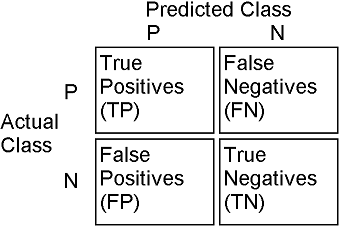


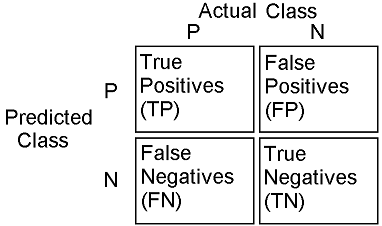

In [ ]:
# Import metrics function
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute accuracy
accuracy_score = knn.score(X_test, y_test)
print('Accuracy: {0:0.4f}'.format(accuracy_score))

# Compute the recall score (weighted vs macro)
macro_recall = recall_score(y_test, y_pred, average = "macro" )
print('Macro recall score: {0:0.4f}'.format(macro_recall))

weighted_recall = recall_score(y_test, y_pred, average = "weighted")
print('Weighted recall score: {0:0.4f}'.format(weighted_recall))

#Compute the precision score (weighted vs macro)
macro_precision = precision_score(y_test, y_pred, average = "macro" )
print('Macro precision score: {0:0.4f}'.format(macro_precision))

weighted_precision = precision_score(y_test, y_pred, average = "weighted")
print('Weighted precision score: {0:0.4f}'.format(weighted_precision))

#Compute the F1 score (weighted vs macro)
macro_f1 = f1_score(y_test, y_pred, average = "macro")
print('Macro f1 score: {0:0.4f}'.format(macro_f1))

weighted_f1 = f1_score(y_test, y_pred, average = "weighted")
print('Weighted f1 score: {0:0.4f}'.format(weighted_f1))

**Confusion matrix and classification report**

In [ ]:
from sklearn.metrics import confusion_matrix

# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


**Plotting the confusion matrix**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot normalized confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(target)
)
display.plot(cmap=plt.cm.Blues)
plt.title("Normalized confusion matrix")
plt.show()